In [147]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [148]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from pydantic import BaseModel,Field

In [149]:
import requests

GREENHOUSE_COMPANIES = [
    "openai",
    "stripe",
    "notion",
    "airbnb",
    "figma",
    "coinbase"
]

#### 1.Prompt Chaining -Job Application Assistant

In [150]:
class ChainState(TypedDict):
    user_query:str
    job_search:list
    resume_summary:str
    cover_letter:str

##### job search agent

In [151]:
def search_jobs_agent(state:ChainState)->ChainState:
    query = state["user_query"]
    jobs = []

    for company in GREENHOUSE_COMPANIES:

        url = (
            f"https://boards-api.greenhouse.io/v1/"
            f"boards/{company}/jobs?content=true"
        )

        response = requests.get(url)

        if response.status_code != 200:
            continue

        data = response.json()

        for job in data["jobs"]:

            title = job["title"].lower()

            if query in title:

                jobs.append({
                    "company": company,
                    "title": job["title"],
                    "location": job["location"]["name"],
                    "url": job["absolute_url"],
                    "description": job["content"]
                })

    return {**state,"job_search":jobs}

##### resume summary agent

In [152]:
def generate_resume_summary(state: ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "resume_summary": "No matching jobs found."
        }
    prompt=f"""
    You're a resume assistant. read the following job description and summarize
    the key qualifications and experience the ideal candidate should have,phrased as
    if from the perspective of a strong applicant's resume summary.
    
    Job Description:
    {state['job_search'][0]['description']}
    
    """
    response=llm.invoke(prompt)
    return {**state,"resume_summary":response.content}

##### generate cover letter agent

In [153]:
def generate_cover_letter(state:ChainState)->ChainState:
    if not state["job_search"]:
        return {
            **state,
            "cover_letter": "No matching jobs found."
        }
    prompt=f"""
    You're a cover letter writing assistant. Using the resume summary below,
    write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['job_search'][0]['description']}
    """
    
    response=llm.invoke(prompt)
    
    return {**state,"cover_letter":response.content}

##### initializing the langgraph workflow

In [154]:
workflow=StateGraph(ChainState)
workflow

In [155]:
workflow.add_node('job_search',search_jobs_agent)
workflow.add_node('generate_resume_summary',generate_resume_summary)
workflow.add_node('generate_cover_letter',generate_cover_letter)
workflow.set_entry_point('job_search')
workflow.add_edge('job_search','generate_resume_summary')
workflow.add_edge('generate_resume_summary','generate_cover_letter')
workflow.set_finish_point('generate_cover_letter')

In [156]:
app=workflow.compile()

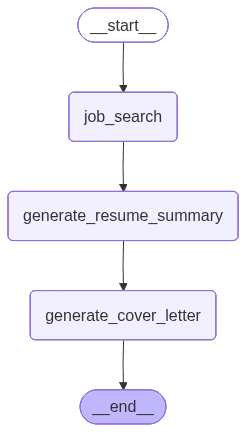

In [157]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [158]:
input_state = {
        "user_query": "data scientist"
}
result=app.invoke(input_state)

In [159]:
result['job_search']

[{'company': 'stripe',
  'title': 'Data Scientist',
  'location': 'Seattle, WA',
  'url': 'https://stripe.com/jobs/search?gh_jid=7809414',
  'description': '&lt;h2&gt;&lt;strong&gt;Who we are &lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;About Stripe&lt;/strong&gt;&lt;/h3&gt;\n&lt;p&gt;&lt;span style=&quot;font-weight: 400;&quot;&gt;Stripe is a financial infrastructure platform for businesses. Millions of companies - from the world’s largest enterprises to the most ambitious startups - use Stripe to accept payments, grow their revenue, and accelerate new business opportunities. Our mission is to increase the GDP of the internet, and we have a staggering amount of work ahead. That means you have an unprecedented opportunity to put the global economy within everyone&#39;s reach while doing the most important work of your career.&lt;/span&gt;&lt;/p&gt;\n&lt;h2&gt;&lt;strong&gt;What you’ll do&lt;/strong&gt;&lt;/h2&gt;\n&lt;h3&gt;&lt;strong&gt;Responsibilities&lt;/strong&gt;&lt;/h3&gt

In [162]:
from pprint import pprint
pprint(result['resume_summary'])

('# Resume Summary\n'
 '\n'
 "**Senior Data Scientist** with a Master's degree in Computer "
 'Science/Statistics and 3+ years of experience driving data-informed '
 'decision-making at scale. Proven track record partnering with Sales and '
 'cross-functional product teams to translate complex business questions into '
 'actionable insights and production-ready solutions.\n'
 '\n'
 '**Core Competencies:**\n'
 '\n'
 '- **Advanced Analytics & Modeling:** Applies statistical methods, time '
 'series forecasting, and machine learning models to large-scale datasets to '
 'predict user and product performance.\n'
 '- **End-to-End Data Science Solutions:** Designs, implements, and launches '
 'full-stack data science products from ideation through productionalization.\n'
 '- **Production Engineering:** 2+ years productionalizing machine learning '
 'models and software products, with deep experience designing and analyzing '
 'software architectures.\n'
 '- **ETL & Data Engineering:** Builds 

In [163]:
pprint(result['cover_letter'])

('# Cover Letter: Senior Data Scientist at Stripe\n'
 '\n'
 'Dear Stripe Hiring Team,\n'
 '\n'
 "When I read that Stripe's mission is to increase the GDP of the internet, it "
 "crystallized something I've been looking for in my next role: a place where "
 'data science work has the potential to move markets, not just metrics. With '
 "a Master's degree in Computer Science/Statistics and over three years of "
 'experience partnering with Sales and product teams to ship data-driven '
 'solutions at scale, I am thrilled to apply for the Senior Data Scientist '
 'position.\n'
 '\n'
 "Throughout my career, I've specialized in exactly the work this role "
 'demands. I design and apply statistical methods, time series forecasting, '
 'and machine learning models to large-scale datasets to predict user and '
 'product performance. In my current role, I have built forecasting models '
 'that surface forward-looking revenue signals directly to Sales leadership, '
 'and I have partnered with pro

In [ ]:
class graphstate(TypedDict):
    resume_path:str
    resume_text:str
    resume_skills:list
    resume_experience:list
    resume_project:list
    resume_education:list

In [190]:
from langchain_community.document_loaders import PyPDFLoader
def load_pdf_agent(state:graphstate)->graphstate:
    resume_path=state['resume_path']
    loader = PyPDFLoader(resume_path)
    docs = loader.load()

    text = "\n".join(doc.page_content for doc in docs)
    return {**state,"resume_text":text}

In [191]:
def skill_extraction_agent(state):

    prompt = f"""
    Extract all technical skills from this resume.

    Resume:
    {state['resume_text']}

    Return only a Python list.

    Example:
    ["Python","SQL","TensorFlow"]
    """

    response = llm.invoke(prompt)

    return {
        **state,
        "resume_skills": response.content
    }

In [196]:
workflow=StateGraph(graphstate)
workflow

In [197]:

workflow.add_node('load_pdf_agent',load_pdf_agent)
workflow.add_node('skill_extraction_agent',skill_extraction_agent)
workflow.set_entry_point('load_pdf_agent')
workflow.add_edge('load_pdf_agent','skill_extraction_agent')
workflow.set_finish_point('skill_extraction_agent')

In [198]:
app=workflow.compile()

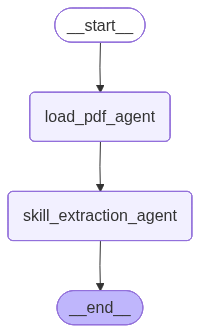

In [199]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [200]:
input_state = {
        "resume_path": "data_scientist_resume_sample.pdf"
}
result=app.invoke(input_state)

In [201]:
pprint(result['resume_text'])

('John Doe\n'
 'Data Scientist\n'
 'Email: john.doe@email.com | Phone: +1-555-123-4567 | LinkedIn: '
 'linkedin.com/in/johndoe |\n'
 'GitHub: github.com/johndoe\n'
 'Professional Summary\n'
 'Results-driven Data Scientist with 3+ years of experience in machine '
 'learning, data analysis, and\n'
 'predictive modeling. Proficient in Python, SQL, TensorFlow, scikit-learn, '
 'and data visualization\n'
 'tools.\n'
 'Technical Skills\n'
 'Python, SQL, Pandas, NumPy, Scikit-learn, TensorFlow, PyTorch, Matplotlib, '
 'Seaborn, Power BI,\n'
 'Tableau, Git, Docker\n'
 'Experience\n'
 'Data Scientist, ABC Analytics (2023-Present) - Developed customer churn '
 'prediction models\n'
 'improving retention by 15%. - Built ETL pipelines and automated reporting '
 'dashboards. - Applied\n'
 'NLP techniques for sentiment analysis.\n'
 'Projects\n'
 '\x7f House Price Prediction using XGBoost \x7f Customer Segmentation with '
 'K-Means Clustering \x7f\n'
 'NLP-based Sentiment Analysis System\n'
 'Educat

In [202]:
pprint(result['resume_skills'])

('["Python", "SQL", "Pandas", "NumPy", "Scikit-learn", "TensorFlow", '
 '"PyTorch", "Matplotlib", "Seaborn", "Power BI", "Tableau", "Git", "Docker", '
 '"XGBoost"]')
